In [2]:
import pandas as pd

df = pd.read_csv("TSLA.csv")

print("Shape of Dataset:", df.shape)
df.head()

Shape of Dataset: (2416, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [4]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

# Tesla Stock Price Prediction using SimpleRNN and LSTM
## 1. Importing Required Libraries

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Loading Dataset

In [6]:
df = pd.read_csv("TSLA.csv")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [7]:
## 3. Dataset Overview

In [8]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2416
Number of Columns : 7


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [10]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


## 4. Missing Value Analysis

In [11]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

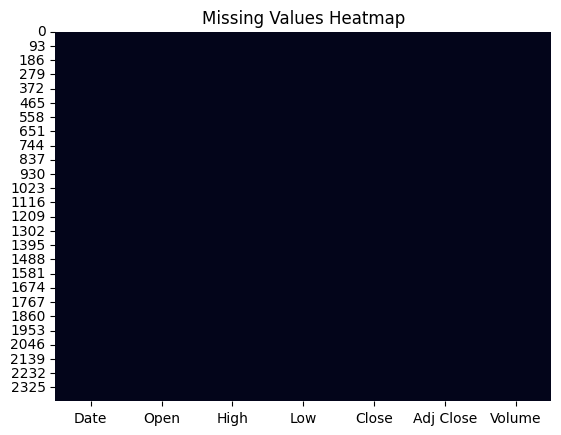

In [12]:
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

## 5. Duplicate Value Analysis

In [13]:
df.duplicated().sum()

0

## 6. Converting Date Column

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [15]:
df.set_index('Date', inplace=True)

df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


## 7. Closing Price Trend Analysis

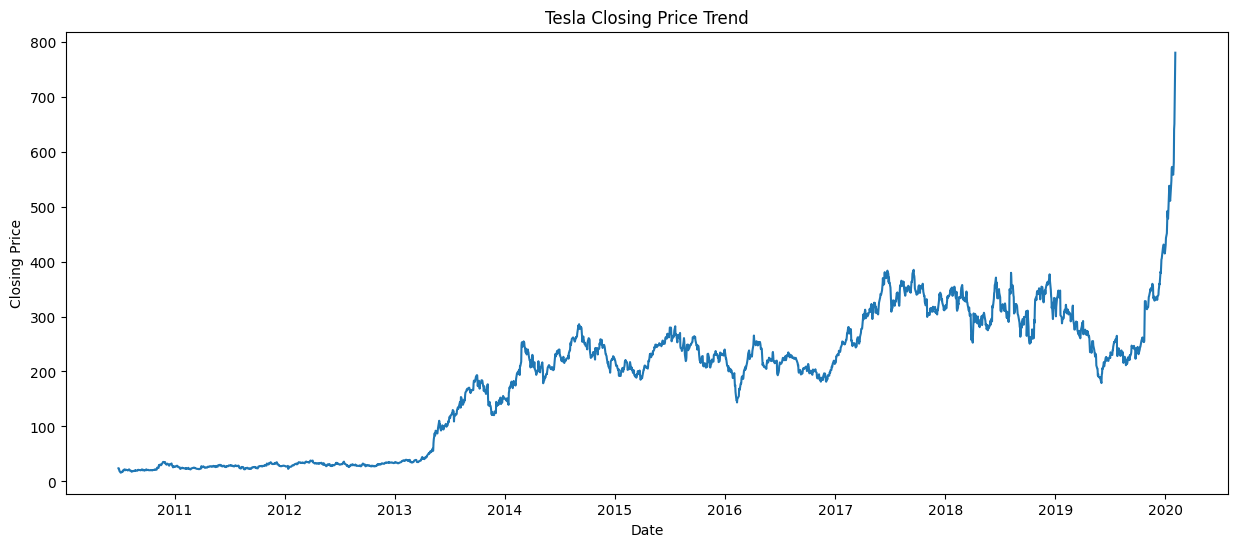

In [16]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'])

plt.title("Tesla Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

### Observation
The Tesla stock closing price shows an overall increasing trend over time with noticeable fluctuations, indicating market volatility.

## 8. Trading Volume Analysis

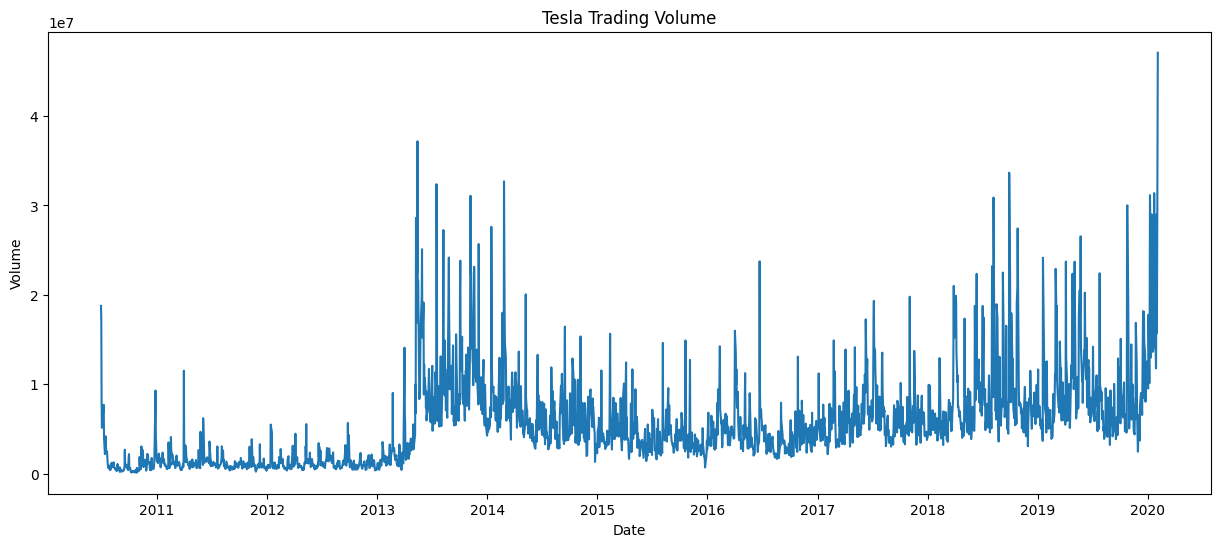

In [17]:
plt.figure(figsize=(15,6))

plt.plot(df['Volume'])

plt.title("Tesla Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

### Observation
Trading volume varies significantly across different periods, indicating varying investor interest and market activity.

## 9. Distribution of Closing Price

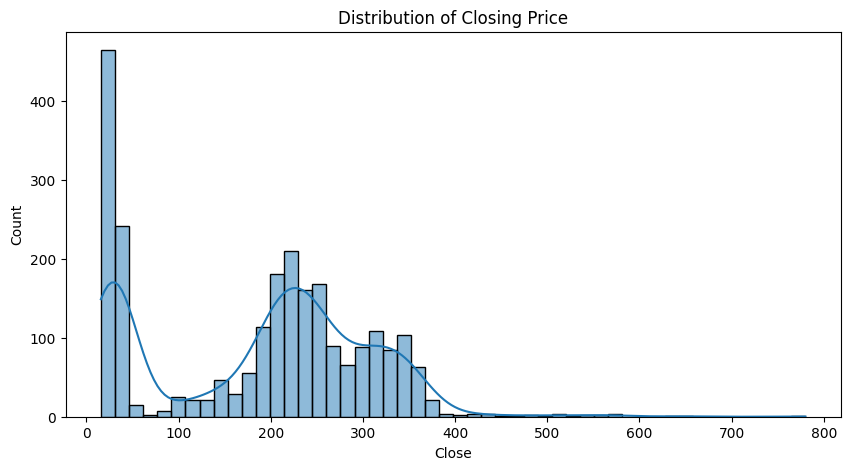

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df['Close'], bins=50, kde=True)

plt.title("Distribution of Closing Price")

plt.show()

10. Moving Average Analysis

In [19]:
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

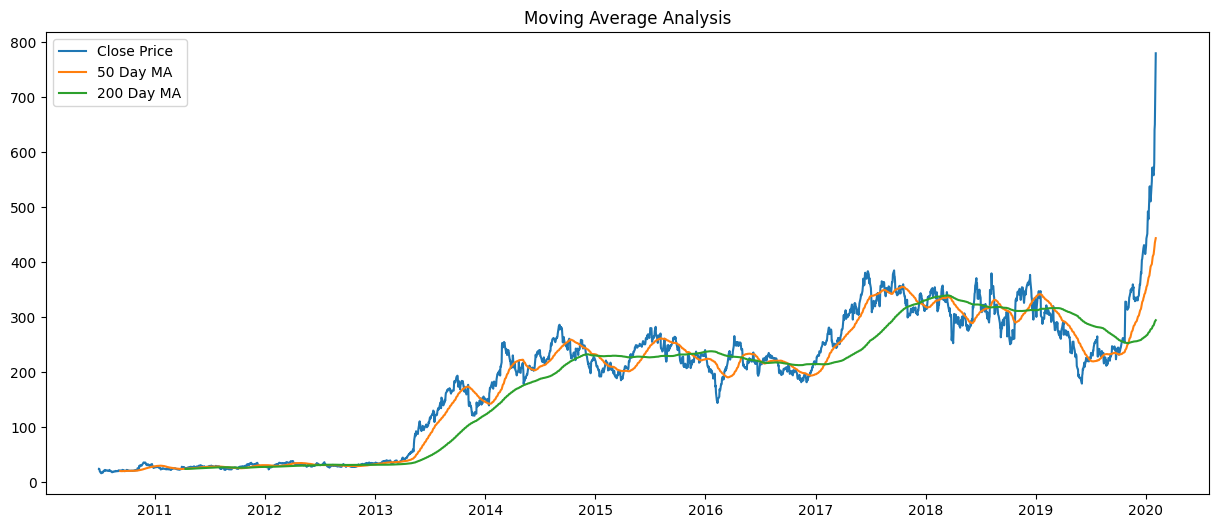

In [20]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA50'], label='50 Day MA')
plt.plot(df['MA200'], label='200 Day MA')

plt.legend()

plt.title("Moving Average Analysis")

plt.show()

### Observation
The moving averages smooth out short-term fluctuations and help identify long-term trends in Tesla stock prices.

## 11. Correlation Analysis

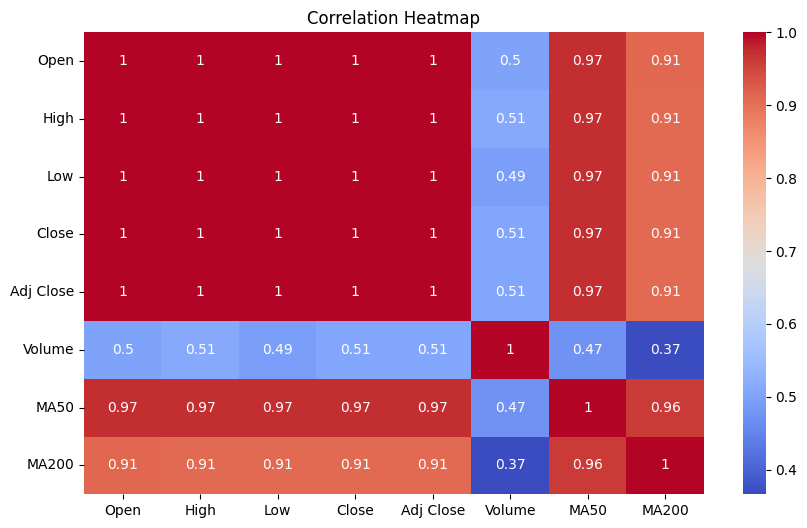

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## 12. Daily Returns

In [22]:
df['Daily_Return'] = df['Close'].pct_change()

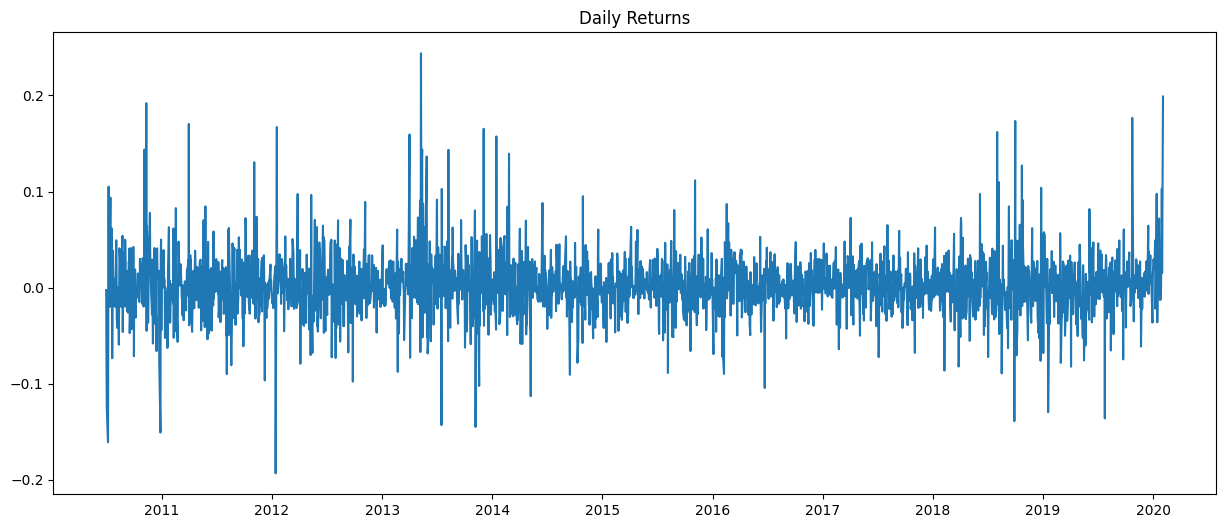

In [23]:
plt.figure(figsize=(15,6))

plt.plot(df['Daily_Return'])

plt.title("Daily Returns")

plt.show()

## 13. Target Variable Selection

In [24]:
data = df[['Close']]
data.head()

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


## 14. Data Normalization using MinMaxScaler

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

scaled_data

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       ...,
       [0.81786181],
       [0.83063335],
       [1.        ]])

## 15: Train-Test Split

In [26]:
training_size = int(len(scaled_data) * 0.80)

train_data = scaled_data[:training_size]
test_data = scaled_data[training_size:]

print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)

Training Data Shape: (1932, 1)
Testing Data Shape: (484, 1)


## 16: Sequence Creation

In [27]:
def create_dataset(dataset, time_step=60):

    X, y = [], []

    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i + time_step, 0])

    return np.array(X), np.array(y)

In [28]:
time_step = 60

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

print(X_train.shape)
print(y_train.shape)

(1871, 60)
(1871,)


## 17: Reshape for RNN/LSTM

In [29]:
X_train = X_train.reshape(X_train.shape[0],
                          X_train.shape[1],
                          1)

X_test = X_test.reshape(X_test.shape[0],
                        X_test.shape[1],
                        1)

print(X_train.shape)
print(X_test.shape)

(1871, 60, 1)
(423, 60, 1)


## 18. Building SimpleRNN Model

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [31]:
simple_rnn = Sequential()

simple_rnn.add(
    SimpleRNN(
        units=50,
        return_sequences=False,
        input_shape=(60,1)
    )
)

simple_rnn.add(Dropout(0.2))

simple_rnn.add(Dense(1))

simple_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

## 19: Compile Model

In [33]:
simple_rnn.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

## 20: Early Stopping

In [35]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [36]:
history_rnn = simple_rnn.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0042 - val_loss: 0.0016
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 8.2879e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.3997e-04 - val_loss: 6.5395e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.3281e-04 - val_loss: 6.0296e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.3117e-04 - val_loss: 5.6547e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.1550e-04 - val_loss: 4.6920e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.3032e-04 - val_loss: 4.1754e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.0146e-04 - val_loss: 5.9251e-04
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.0742e-04 - val_loss: 0.0012
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5790e-04 - val_loss: 3.5648e-04
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.0863e-04 - val_loss: 3.

## 22: Loss Curve

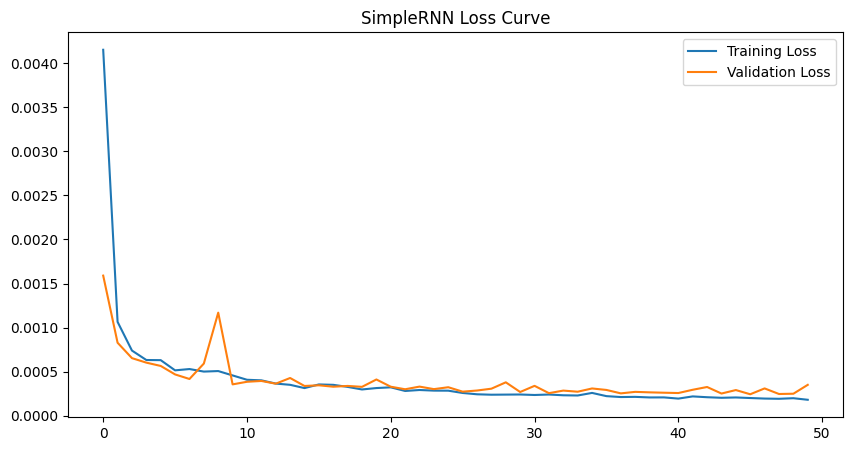

In [37]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("SimpleRNN Loss Curve")

plt.show()

## 23: Prediction

In [38]:
rnn_predictions = simple_rnn.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


## 24: Inverse Transform

In [39]:
rnn_predictions = scaler.inverse_transform(rnn_predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

## 25: Evaluation

In [40]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rnn_mse = mean_squared_error(
    y_test_actual,
    rnn_predictions
)

rnn_rmse = np.sqrt(rnn_mse)

rnn_mae = mean_absolute_error(
    y_test_actual,
    rnn_predictions
)

rnn_r2 = r2_score(
    y_test_actual,
    rnn_predictions
)

print("MSE :", rnn_mse)
print("RMSE :", rnn_rmse)
print("MAE :", rnn_mae)
print("R2 Score :", rnn_r2)

MSE : 142.68356855699903
RMSE : 11.945022752468873
MAE : 8.109773532263501
R2 Score : 0.9730984060074801


## 26: Actual vs Predicted Graph

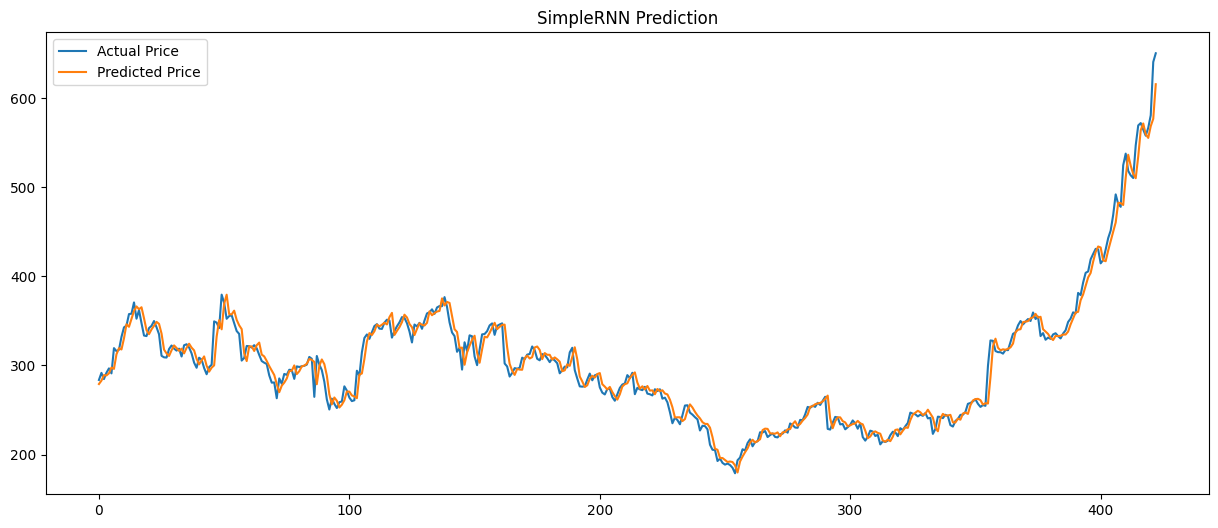

In [41]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    rnn_predictions,
    label='Predicted Price'
)

plt.title("SimpleRNN Prediction")

plt.legend()

plt.show()

## LSTM Model

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [43]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(60,1)
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [45]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0047 - val_loss: 0.0011
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.6310e-04 - val_loss: 9.2420e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.1487e-04 - val_loss: 9.5796e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.4583e-04 - val_loss: 8.4170e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.9906e-04 - val_loss: 8.0662e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.7743e-04 - val_loss: 0.0011
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.3314e-04 - val_loss: 9.8975e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.3328e-04 - val_loss: 0.0010
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 4.2984e-04 - val_loss: 7.9595e-04
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.2171e-04 - val_loss: 6.6622e-04


In [46]:
lstm_predictions = lstm_model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [47]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

In [48]:
lstm_mse = mean_squared_error(
    y_test_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(lstm_mse)

lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)

lstm_r2 = r2_score(
    y_test_actual,
    lstm_predictions
)

print("MSE :", lstm_mse)
print("RMSE :", lstm_rmse)
print("MAE :", lstm_mae)
print("R2 Score :", lstm_r2)

MSE : 652.0266162124746
RMSE : 25.534811849952497
MAE : 20.70067476316397
R2 Score : 0.8770667465142807


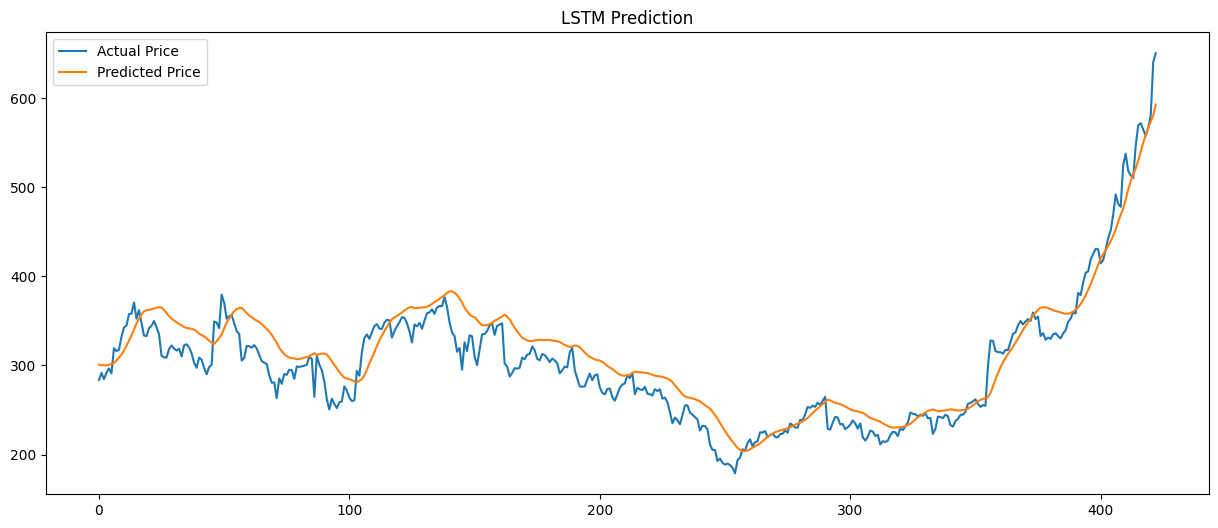

In [49]:
plt.figure(figsize=(15,6))

plt.plot(y_test_actual,
         label='Actual Price')

plt.plot(lstm_predictions,
         label='Predicted Price')

plt.title("LSTM Prediction")

plt.legend()

plt.show()

## SimpleRNN Save

In [50]:
simple_rnn.save("simple_rnn.keras")

## LSTM Save

In [51]:
lstm_model.save("lstm_model.keras")

## Final Comparison Graph

In [53]:
comparison = pd.DataFrame({
    'Model':['SimpleRNN','LSTM'],
    'RMSE':[rnn_rmse,lstm_rmse]
})

comparison

,Model,RMSE
0,SimpleRNN,11.945023
1,LSTM,25.534812


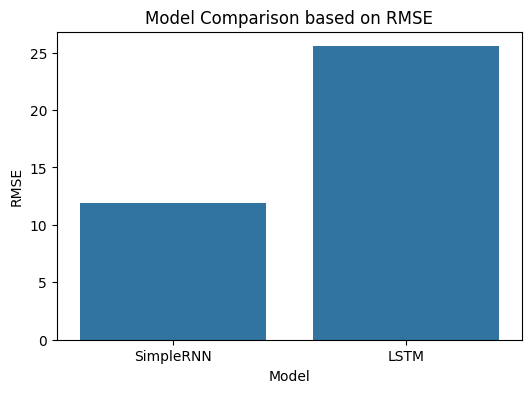

In [54]:
plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='RMSE', data=comparison)

plt.title("Model Comparison based on RMSE")
plt.show()

## Future Prediction Function

In [59]:
def future_prediction(model, last_sequence, future_days):

    temp_input = last_sequence.flatten().tolist()

    predictions = []

    for _ in range(future_days):

        x_input = np.array(temp_input[-60:])
        x_input = x_input.reshape(1, 60, 1)

        yhat = model.predict(x_input, verbose=0)

        predicted_value = yhat[0][0]

        predictions.append(predicted_value)
        temp_input.append(predicted_value)

    predictions = np.array(predictions).reshape(-1,1)

    return scaler.inverse_transform(predictions)

## Last 60 Days Data

In [60]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1,60,1)

## 1-Day Prediction

In [61]:
future_1_day = future_prediction(
    simple_rnn,
    last_60_days,
    1
)

print("Next Day Predicted Price:")
print(future_1_day)

Next Day Predicted Price:
[[730.08813]]


## 5-Day Prediction

In [62]:
future_5_days = future_prediction(
    simple_rnn,
    last_60_days,
    5
)

print("Next 5 Days Prediction:")
print(future_5_days)

Next 5 Days Prediction:
[[730.08813]
 [743.1393 ]
 [729.40845]
 [728.99677]
 [727.054  ]]


## 10-Day Prediction

In [64]:
future_10_days = future_prediction(
    simple_rnn,
    last_60_days,
    10
)

print("Next 10 Days Prediction:")
print(future_10_days)

Next 10 Days Prediction:
[[730.08813]
 [743.1393 ]
 [729.40845]
 [728.99677]
 [727.054  ]
 [723.899  ]
 [718.27673]
 [715.2686 ]
 [705.73804]
 [704.3845 ]]


## Visualize 10-Day Forecast

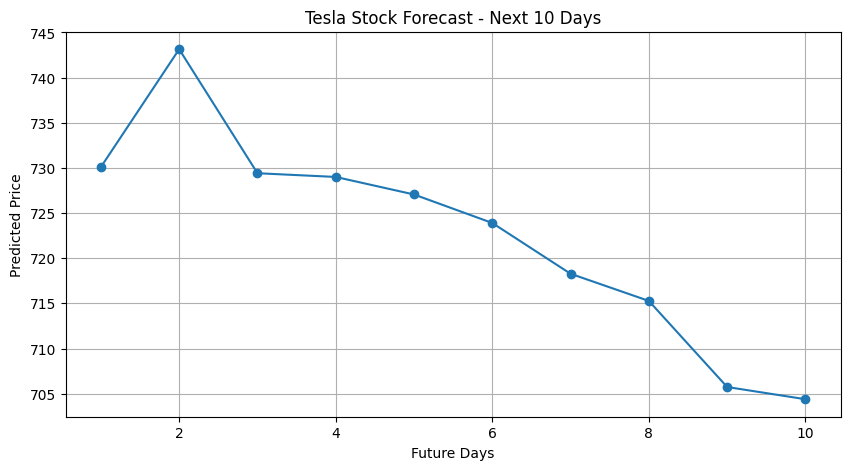

In [65]:
future_days = np.arange(1,11)

plt.figure(figsize=(10,5))

plt.plot(
    future_days,
    future_10_days,
    marker='o'
)

plt.title("Tesla Stock Forecast - Next 10 Days")
plt.xlabel("Future Days")
plt.ylabel("Predicted Price")

plt.grid(True)

plt.show()

## Model Saving

In [67]:
simple_rnn.save("simple_rnn.keras")
lstm_model.save("lstm_model.keras")

print("Models Saved Successfully!")

Models Saved Successfully!


## Report Observation

The trained SimpleRNN model was used to forecast Tesla stock prices for the next 1, 5, and 10 trading days. The prediction results indicate a short-term downward trend after an initial increase. The forecast suggests that Tesla's stock price may gradually decline over the next 10 trading days based on historical market behavior.

## Conclusion

This project focused on predicting Tesla stock closing prices using Deep Learning techniques, specifically SimpleRNN and LSTM models. The dataset was successfully preprocessed through data cleaning, missing value analysis, feature scaling, and time-series sequence creation. Exploratory Data Analysis (EDA) was performed to understand stock price trends, trading volume patterns, moving averages, and correlations among features.

Both SimpleRNN and LSTM models were trained and evaluated on historical Tesla stock data. The SimpleRNN model achieved superior performance, with an RMSE of 11.95 and an R² Score of 97.31%, whereas the LSTM model achieved an RMSE of 25.53 and an R² Score of 87.71%. Based on these results, SimpleRNN was selected as the best-performing model for this dataset.

The trained model was further used to forecast Tesla stock prices for the next 1 day, 5 days, and 10 days, demonstrating its capability to capture short-term market trends. The prediction results indicated a slight downward movement in Tesla’s stock price over the forecast horizon.

Overall, the project successfully demonstrated the application of Deep Learning techniques for stock price prediction. Future improvements may include incorporating additional features such as news sentiment analysis, macroeconomic indicators, trading signals, and advanced models like GRU, Transformers, or hybrid deep learning architectures to further improve prediction accuracy.